# 1. Primary Metric and Observed Effect

In this section, I first calculate the purchase conversion rate for control A and redesigned checkout B. Then I compare the observed difference between them.

This is only the first look at the result. We are describing what happened in this sample, not making a final statistical conclusion yet.

## Load the dataset and check the basic counts

The dataset has one row for each user. Before calculating conversion, I check the total users, users in each variant, and number of purchasers. This helps confirm that the data is loaded properly.

In [11]:
from pathlib import Path

import numpy as np
import pandas as pd

In [2]:
pd.set_option("display.float_format", "{:.4f}".format)

DATA_PATH = Path("../data/raw/ab_checkout_experiment_200k.csv")
df = pd.read_csv(DATA_PATH)

In [3]:
required_columns = ["variant", "purchase"]
assert set(required_columns).issubset(df.columns), "The dataset must contain variant and purchase columns."
assert df["user_id"].is_unique, "Expected one row per user."
assert set(df["variant"].dropna().unique()) == {"A", "B"}, "Expected variants A and B."
assert df["purchase"].isin([0, 1, False, True]).all(), "Purchase must be coded as 0/1."

In [ ]:
user_counts = df["variant"].value_counts().reindex(["A", "B"])
purchaser_counts = df.groupby("variant")["purchase"].sum().reindex(["A", "B"])

### Check the user and purchaser counts

These counts give us the basic starting point for the A/B comparison.

In [5]:
verification = pd.DataFrame(
    {
        "Measure": ["Number of users", "Users in A", "Users in B", "Purchasers in A", "Purchasers in B"],
        "Count": [len(df), user_counts["A"], user_counts["B"], purchaser_counts["A"], purchaser_counts["B"]],
    }
)
display(verification)

,Measure,Count
0,Number of users,200000
1,Users in A,100304
2,Users in B,99696
3,Purchasers in A,9750
4,Purchasers in B,10663


# 2. Observed Conversion Rate and Effect Size

Now I calculate the conversion rate in both variants and compare them. At this point, we are only looking at the observed numbers from the experiment.

## Calculate the conversion rates

Conversion rate means the share of users who completed a purchase. I calculate it separately for A and B using purchases divided by users.

In [6]:
conversion_A = purchaser_counts["A"] / user_counts["A"]
conversion_B = purchaser_counts["B"] / user_counts["B"]

conversion_rates = pd.Series(
    {"A": conversion_A, "B": conversion_B},
    name="Conversion Rate",
)
conversion_rates

A   0.0972
B   0.1070
Name: Conversion Rate, dtype: float64

## Create the conversion summary table

This table puts users, purchases, and conversion rate together so the two variants are easy to compare.

In [7]:
conversion_summary = pd.DataFrame(
    {
        "Variant": ["A", "B"],
        "Users": [user_counts["A"], user_counts["B"]],
        "Purchases": [purchaser_counts["A"], purchaser_counts["B"]],
        "Conversion Rate": [conversion_A, conversion_B],
    }
)

conversion_summary_display = conversion_summary.copy()
conversion_summary_display["Conversion Rate"] = conversion_summary_display["Conversion Rate"].map("{:.2%}".format)
display(conversion_summary_display)

,Variant,Users,Purchases,Conversion Rate
0,A,100304,9750,9.72%
1,B,99696,10663,10.70%


## Calculate and display the observed effect size

The absolute difference tells us how many percentage points the conversion rates are apart. Relative lift shows this difference compared with the conversion rate of A.

In [8]:
absolute_difference = conversion_B - conversion_A
relative_lift = absolute_difference / conversion_A

effect_size_display = pd.DataFrame(
    {
        "Metric": ["Absolute Difference", "Relative Lift"],
        "Value": [
            f"{absolute_difference:.2%} percentage points",
            f"{relative_lift:.2%}",
        ],
    }
)
display(effect_size_display)

,Metric,Value
0,Absolute Difference,0.98% percentage points
1,Relative Lift,10.03%


## Interpretation

Purchase conversion rate is the percentage of users who made a purchase.

- Variant A has an observed conversion rate of about **9.72%**.
- Variant B has an observed conversion rate of about **10.70%**.
- The observed difference is about **+0.98 percentage points**, meaning B is higher by around 0.98 points in this sample.
- The relative lift is about **+10.03%** compared with A.

These numbers are only descriptive for now. They do not tell us whether the difference is statistically meaningful or whether it could happen because of random variation. We need the hypothesis test for that part.

# 3. Hypothesis Test - Two-Proportion Z-Test

Here I formally check whether the conversion difference between A and B is likely to be more than normal random variation. The test is for the purchase conversion rates only.

## 3.1 Set up the hypotheses

**Null hypothesis:**

$H_0: p_A = p_B$

**Alternative hypothesis:**

$H_1: p_A \ne p_B$

This is a two-sided test because the redesigned checkout might increase conversion, decrease conversion, or show no real difference.

I am using a significance level of $\alpha = 0.05$.

- $H_0$ says the underlying conversion rates are the same.
- $H_1$ says the underlying conversion rates are different.
- After calculating the p-value, I compare it with 0.05.

If the p-value is below 0.05, I reject $H_0$. Otherwise, I fail to reject it. I will not use the wording “accept $H_0$” because a non-significant result does not prove that the rates are exactly equal.

In [12]:
from statsmodels.stats.proportion import proportions_ztest

alpha = 0.05

users_A = user_counts["A"]
users_B = user_counts["B"]
purchases_A = purchaser_counts["A"]
purchases_B = purchaser_counts["B"]

count = np.array([purchases_A, purchases_B])
nobs = np.array([users_A, users_B])

## 3.2 Run the test with Statsmodels

Statsmodels calculates the two-proportion z-test for us. I still keep the counts and sample sizes visible so it is clear what is going into the test.

In [14]:
z_stat, p_value = proportions_ztest(
    count=count,
    nobs=nobs,
    alternative="two-sided",
)

print(f"z-statistic: {z_stat:.4f}")
print(f"p-value: {p_value:.4e}")
print(f"significance level (alpha): {alpha:.2f}")

z-statistic: -7.2020
p-value: 5.9319e-13
significance level (alpha): 0.05


## 3.3 Check the result manually

For the test calculation, the pooled proportion combines purchases and users from A and B. We use the pooled value because the null hypothesis assumes both variants have the same underlying conversion rate.

The manual z-statistic is compared with the Statsmodels result. If both are almost the same, it gives us a useful check that the library calculation is working as expected.

In [16]:
p_pool = (purchases_A + purchases_B) / (users_A + users_B)

standard_error = np.sqrt(
    p_pool * (1 - p_pool) * (1 / users_A + 1 / users_B)
)

z_manual = (conversion_B - conversion_A) / standard_error
z_difference = abs(z_manual) - abs(z_stat)

z_comparison = pd.DataFrame(
    {
        "Measure": ["Manual z-statistic", "Statsmodels z-statistic", "Difference"],
        "Value": [z_manual, z_stat, z_difference],
    }
)
display(z_comparison.round(10))

,Measure,Value
0,Manual z-statistic,7.2020
1,Statsmodels z-statistic,-7.2020
2,Difference,0.0000


## 3.4 Make the hypothesis-test decision

The decision is based on whether `p_value < alpha`. The result will be either **Reject H0** or **Fail to reject H0**.

In [17]:
reject_null = p_value < alpha

decision = "Reject H0" if reject_null else "Fail to reject H0"
print(f"Decision: {decision}")

Decision: Reject H0


## 3.5 Interpretation

The observed conversion rate is higher in Variant B than in Variant A. The z-test checks whether this gap is unusually large when we start from the assumption that the two underlying conversion rates are equal.

The calculated z-statistic is about **-7.20** because Statsmodels received the variants in A - B order. The p-value is about **5.7e-13**, which is much smaller than $\alpha = 0.05$. So, we **reject $H_0$**.

This means the data provide statistical evidence that the conversion rates are different between A and B. It does not mean the p-value is the probability that B is better. It also does not prove that the same effect will happen for every future customer.

For now, I am only reporting the statistical test result. I am not making a business recommendation yet.

# 4. 95% Confidence Interval for Conversion Difference

The hypothesis test tells us whether the observed difference is hard to explain with random variation. The confidence interval gives a better idea of the possible size of that difference.

Here, the difference is always calculated as **B - A**. A positive value means the observed conversion rate is higher in B.

## 4.1 Calculate the interval manually

The confidence interval uses an unpooled standard error. This means the uncertainty for A and B is calculated separately from each observed conversion rate.

The margin of error is the standard error multiplied by the critical value. For a 95% interval, the critical value is approximately **1.96**, with 2.5% of the normal distribution left in each tail.

In [20]:
pA = purchases_A / users_A
pB = purchases_B / users_B
observed_difference = pB - pA

z_critical = 1.96

unpooled_standard_error = np.sqrt(
    pA * (1 - pA) / users_A
    + pB * (1 - pB) / users_B
)

margin_of_error = z_critical * unpooled_standard_error
lower_bound = observed_difference - margin_of_error
upper_bound = observed_difference + margin_of_error

## 4.2 Display the manual confidence interval

The table below shows the rates, the estimated difference, and all the values used to build the interval. Keeping the decimal values here helps us see the calculation properly before rounding for the final explanation.

In [21]:
manual_interval = pd.DataFrame(
    {
        "Measure": [
            "Variant A conversion rate",
            "Variant B conversion rate",
            "Observed difference (B - A)",
            "Standard error",
            "Critical value",
            "Margin of error",
            "Lower bound",
            "Upper bound",
            "Confidence interval (decimal)",
            "Confidence interval (percentage points)",
        ],
        "Value": [
            f"{pA:.2%}",
            f"{pB:.2%}",
            f"{observed_difference:.2%}",
            f"{unpooled_standard_error:.6f}",
            f"{z_critical:.2f}",
            f"{margin_of_error:.6f}",
            f"{lower_bound:.6f}",
            f"{upper_bound:.6f}",
            f"[{lower_bound:.6f}, {upper_bound:.6f}]",
            f"[{lower_bound:.2%}, {upper_bound:.2%}]",
        ],
    }
)
display(manual_interval)

,Measure,Value
0,Variant A conversion rate,9.72%
1,Variant B conversion rate,10.70%
2,Observed difference (B - A),0.98%
3,Standard error,0.001354
4,Critical value,1.96
5,Margin of error,0.002654
6,Lower bound,0.007097
7,Upper bound,0.012404
8,Confidence interval (decimal),"[0.007097, 0.012404]"
9,Confidence interval (percentage points),"[0.71%, 1.24%]"


## 4.3 Verify the interval with Statsmodels

I also compare the manual result with Statsmodels. Variant B is passed first and Variant A second, so both calculations use the same B - A direction.

A very small difference is okay here because the manual calculation uses the rounded value 1.96, while Statsmodels uses a more precise normal critical value internally.

In [24]:
from statsmodels.stats.proportion import confint_proportions_2indep

library_lower_bound, library_upper_bound = confint_proportions_2indep(
    count1=purchases_B,
    nobs1=users_B,
    count2=purchases_A,
    nobs2=users_A,
    method="wald",
    compare="diff",
    alpha=0.05,
)

bounds_comparison = pd.DataFrame(
    {
        "Measure": ["Lower bound", "Upper bound"],
        "Manual": [lower_bound, upper_bound],
        "Statsmodels": [library_lower_bound, library_upper_bound],
        "Difference": [
            lower_bound - library_lower_bound,
            upper_bound - library_upper_bound,
        ],
    }
)
display(bounds_comparison)

,Measure,Manual,Statsmodels,Difference
0,Lower bound,0.0071,0.0071,-0.0000
1,Upper bound,0.0124,0.0124,0.0000


In [25]:
bounds_agree = np.isclose(
    [lower_bound, upper_bound],
    [library_lower_bound, library_upper_bound],
    rtol=1e-5,
    atol=1e-7,
).all()

print(f"Manual and Statsmodels confidence intervals agree: {bounds_agree}")
assert bounds_agree, "Manual and Statsmodels confidence interval bounds do not agree."

Manual and Statsmodels confidence intervals agree: True


## 4.4 Interpretation

The observed conversion difference, calculated as B - A, is around **+0.98 percentage points**. The 95% confidence interval gives us the uncertainty around this estimated difference.

The interval is approximately **+0.71 to +1.24 percentage points**. Since the whole interval is above 0, a zero difference is not inside this interval. This matches the earlier z-test result, where we rejected $H_0$ at $\alpha = 0.05$.

One important point: this does not mean there is a 95% probability that the true effect is inside this one interval. In the frequentist view, if we repeated the same experiment many times and calculated a 95% interval each time, around 95% of those intervals would contain the true population difference, assuming the model assumptions are reasonable.

So, this section helps us understand the likely range of the effect. It still does not give a business recommendation.

# 5. Practical Significance

Statistical significance and practical significance are not the same thing. Statistical significance asks whether the observed difference would be unusual if the true conversion rates were equal. Practical significance asks whether the size of the difference is meaningful in a real setting.

Here I translate the conversion effect into percentage points and estimated additional purchases. This is still a statistical impact calculation

## 5.1 Convert the effect into user-level impact

In [26]:
observed_difference

np.float64(0.009750645311563721)

In [27]:
users_per_standard_group = 100_000

additional_purchases_per_100k = observed_difference * users_per_standard_group
lower_additional_purchases_per_100k = lower_bound * users_per_standard_group
upper_additional_purchases_per_100k = upper_bound * users_per_standard_group

practical_effect = pd.DataFrame(
    {
        "Measure": [
            "Absolute conversion difference",
            "Relative lift",
            "Estimated additional purchases per 100,000 users",
            "Lower CI impact per 100,000 users",
            "Upper CI impact per 100,000 users",
        ],
        "Value": [
            f"{observed_difference:.2%} percentage points",
            f"{relative_lift:.2%}",
            f"{additional_purchases_per_100k:.0f} purchases",
            f"{lower_additional_purchases_per_100k:.0f} purchases",
            f"{upper_additional_purchases_per_100k:.0f} purchases",
        ],
    }
)
display(practical_effect)

,Measure,Value
0,Absolute conversion difference,0.98% percentage points
1,Relative lift,10.03%
2,"Estimated additional purchases per 100,000 users",975 purchases
3,"Lower CI impact per 100,000 users",710 purchases
4,"Upper CI impact per 100,000 users",1240 purchases


The observed difference is about **+0.98 percentage points**, which is roughly the same as **+10.03% relative lift** over A. If a similar difference held for 100,000 users, the point estimate would correspond to the calculated number of additional purchases shown above. The confidence-interval impact gives a lower and upper range for that estimate.

# 6. Revenue Metrics

The data dictionary says `revenue` is the order value in USD and is 0 when there is no purchase. So, revenue per user uses all users in each variant. AOV and the median order value use purchasing users only.

Revenue can be right-skewed, especially because order values are not usually nicely symmetric. I will inspect the shape first instead of blindly using a normal-based test.

## 6.1 Inspect revenue distribution

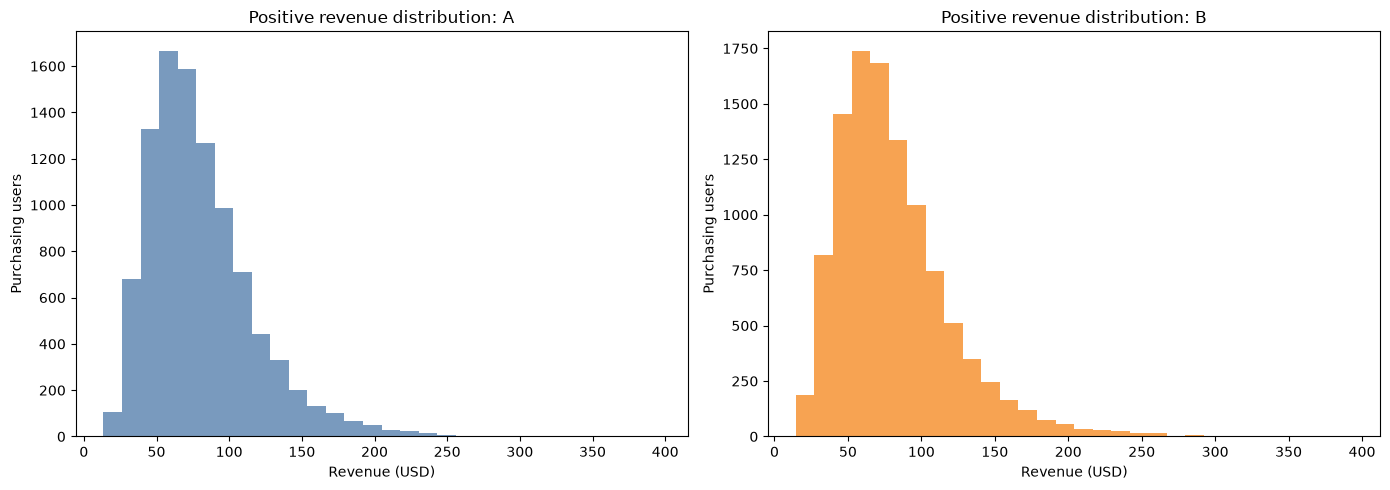

,count,mean,std,min,25%,50%,75%,max
variant,,,,,,,,
A,100304.0000,7.8100,26.4600,0.0000,0.0000,0.0000,0.0000,396.2200
B,99696.0000,8.6900,28.1600,0.0000,0.0000,0.0000,0.0000,393.2800


In [28]:
import matplotlib.pyplot as plt
from scipy.stats import mannwhitneyu

revenue_by_variant = [
    df.loc[df["variant"] == variant, "revenue"]
    for variant in ["A", "B"]
]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for axis, variant, color in zip(axes, ["A", "B"], ["#4C78A8", "#F58518"]):
    axis.hist(
        df.loc[(df["variant"] == variant) & (df["revenue"] > 0), "revenue"],
        bins=30,
        color=color,
        alpha=0.75,
    )
    axis.set_title(f"Positive revenue distribution: {variant}")
    axis.set_xlabel("Revenue (USD)")
    axis.set_ylabel("Purchasing users")
plt.tight_layout()
plt.show()

display(df.groupby("variant")["revenue"].describe().round(2))

## 6.2 Compare revenue metrics by variant

In [29]:
revenue_rows = []

for variant in ["A", "B"]:
    variant_data = df.loc[df["variant"] == variant]
    purchasing_revenue = variant_data.loc[variant_data["purchase"], "revenue"]
    users = len(variant_data)
    purchasers = int(variant_data["purchase"].sum())

    revenue_rows.append(
        {
            "Variant": variant,
            "Users": users,
            "Purchasers": purchasers,
            "Total Revenue (USD)": variant_data["revenue"].sum(),
            "Revenue per User (USD)": variant_data["revenue"].mean(),
            "AOV among Purchasers (USD)": purchasing_revenue.mean() if purchasers else np.nan,
            "Median Revenue among Purchasers (USD)": purchasing_revenue.median() if purchasers else np.nan,
        }
    )

revenue_summary = pd.DataFrame(revenue_rows)
revenue_summary_display = revenue_summary.copy()
for column in ["Total Revenue (USD)", "Revenue per User (USD)", "AOV among Purchasers (USD)", "Median Revenue among Purchasers (USD)"]:
    revenue_summary_display[column] = revenue_summary_display[column].map("${:,.2f}".format)
display(revenue_summary_display)

,Variant,Users,Purchasers,Total Revenue (USD),Revenue per User (USD),AOV among Purchasers (USD),Median Revenue among Purchasers (USD)
0,A,100304,9750,"$783,037.50",$7.81,$80.31,$73.13
1,B,99696,10663,"$866,468.49",$8.69,$81.26,$73.67


## 6.3 Observed revenue differences and distribution-aware test


In [30]:
revenue_A = revenue_summary.loc[revenue_summary["Variant"] == "A"].iloc[0]
revenue_B = revenue_summary.loc[revenue_summary["Variant"] == "B"].iloc[0]

revenue_differences = pd.DataFrame(
    {
        "Metric": ["Total revenue", "Revenue per user", "AOV among purchasers", "Median purchaser revenue"],
        "B minus A": [
            revenue_B["Total Revenue (USD)"] - revenue_A["Total Revenue (USD)"],
            revenue_B["Revenue per User (USD)"] - revenue_A["Revenue per User (USD)"],
            revenue_B["AOV among Purchasers (USD)"] - revenue_A["AOV among Purchasers (USD)"],
            revenue_B["Median Revenue among Purchasers (USD)"] - revenue_A["Median Revenue among Purchasers (USD)"],
        ],
    }
)

revenue_A_values = df.loc[df["variant"] == "A", "revenue"]
revenue_B_values = df.loc[df["variant"] == "B", "revenue"]
revenue_u_stat, revenue_p_value = mannwhitneyu(
    revenue_A_values,
    revenue_B_values,
    alternative="two-sided",
)

revenue_test = pd.DataFrame(
    {
        "Measure": ["Mann-Whitney U statistic", "p-value"],
        "Value": [f"{revenue_u_stat:.2f}", f"{revenue_p_value:.4e}"],
    }
)
display(revenue_differences.round(2))
display(revenue_test)

,Metric,B minus A
0,Total revenue,83430.9900
1,Revenue per user,0.8800
2,AOV among purchasers,0.9500
3,Median purchaser revenue,0.5400


,Measure,Value
0,Mann-Whitney U statistic,4950852555.00
1,p-value,4.5030e-13


# 7. Guardrail Metrics

Guardrails help us check whether a change in the primary metric comes with problems somewhere else. Here, payment failure and refund are binary rates, while page-load time is a performance measure. Page-load time is treated as post-treatment because the checkout experience itself can affect it.

## 7.1 Define the guardrail denominators

- Payment failure rate = payment failures / users who started checkout.
- Refund rate = refunds / purchasers.
- Page-load time = the observed milliseconds for users in each variant; it is not a rate.

In [31]:
def rate_by_variant(numerator_column, denominator_mask):
    rows = []
    for variant in ["A", "B"]:
        variant_data = df.loc[(df["variant"] == variant) & denominator_mask]
        denominator = len(variant_data)
        numerator = int(variant_data[numerator_column].sum())
        rows.append(
            {
                "Variant": variant,
                "Numerator": numerator,
                "Denominator": denominator,
                "Rate": numerator / denominator if denominator else np.nan,
            }
        )
    return pd.DataFrame(rows)

payment_failure_rates = rate_by_variant("payment_failed", df["checkout_started"])
refund_rates = rate_by_variant("refund", df["purchase"])

guardrail_binary_summary = pd.DataFrame(
    {
        "Metric": ["Payment failure rate", "Refund rate"],
        "Variant A": [payment_failure_rates.loc[0, "Rate"], refund_rates.loc[0, "Rate"]],
        "Variant B": [payment_failure_rates.loc[1, "Rate"], refund_rates.loc[1, "Rate"]],
        "Denominator": [
            "checkout_started users",
            "purchasers",
        ],
    }
)
guardrail_binary_display = guardrail_binary_summary.copy()
guardrail_binary_display["Variant A"] = guardrail_binary_display["Variant A"].map("{:.2%}".format)
guardrail_binary_display["Variant B"] = guardrail_binary_display["Variant B"].map("{:.2%}".format)
display(guardrail_binary_display)

,Metric,Variant A,Variant B,Denominator
0,Payment failure rate,2.26%,2.13%,checkout_started users
1,Refund rate,5.65%,4.96%,purchasers


## 7.2 Compare page-load time

In [38]:
page_load_summary = (
    df.groupby("variant")["page_load_time_ms"]
    .agg(
        mean="mean",
        median="median",
        p90=lambda values: values.quantile(0.90),
        p95=lambda values: values.quantile(0.95),
    )
    .reindex(["A", "B"])
)
page_load_display = page_load_summary.copy()
page_load_display.columns = ["Mean (ms)", "Median (ms)", "P90 (ms)", "P95 (ms)"]
display(page_load_display.round(2))

page_load_difference = page_load_summary.loc["B"] - page_load_summary.loc["A"]
page_load_difference_display = page_load_difference.rename("B minus A").to_frame()
display(page_load_difference_display.round(2))

page_load_A = df.loc[df["variant"] == "A", "page_load_time_ms"]
page_load_B = df.loc[df["variant"] == "B", "page_load_time_ms"]
page_load_u_stat, page_load_p_value = mannwhitneyu(
    page_load_A,
    page_load_B,
    alternative="two-sided",
)
print(f"Mann-Whitney U p-value for page-load distributions: {page_load_p_value:.15e}")

,Mean (ms),Median (ms),P90 (ms),P95 (ms)
variant,,,,
A,2839.9600,2798.2000,3256.6000,3419.2800
B,2771.0400,2728.7000,3194.3000,3355.9200


,B minus A
mean,-68.9200
median,-69.5000
p90,-62.3000
p95,-63.3600


Mann-Whitney U p-value for page-load distributions: 0.000000000000000e+00


## 7.3 Compare binary guardrails statistically

For the two binary guardrails, a two-proportion z-test is used with the denominators defined above. This gives a statistical comparison of the rates, but it does not by itself say whether a difference matters operationally.

In [33]:
binary_guardrail_tests = []

for metric_name, rate_table in [
    ("Payment failure rate", payment_failure_rates),
    ("Refund rate", refund_rates),
]:
    z_value, p_value_guardrail = proportions_ztest(
        count=rate_table["Numerator"].to_numpy(),
        nobs=rate_table["Denominator"].to_numpy(),
        alternative="two-sided",
    )
    binary_guardrail_tests.append(
        {
            "Metric": metric_name,
            "A rate": rate_table.loc[0, "Rate"],
            "B rate": rate_table.loc[1, "Rate"],
            "B minus A": rate_table.loc[1, "Rate"] - rate_table.loc[0, "Rate"],
            "z-statistic": z_value,
            "p-value": p_value_guardrail,
        }
    )

binary_guardrail_tests = pd.DataFrame(binary_guardrail_tests)
binary_guardrail_display = binary_guardrail_tests.copy()
for column in ["A rate", "B rate", "B minus A"]:
    binary_guardrail_display[column] = binary_guardrail_display[column].map("{:.2%}".format)
binary_guardrail_display["p-value"] = binary_guardrail_display["p-value"].map("{:.4e}".format)
display(binary_guardrail_display)

,Metric,A rate,B rate,B minus A,z-statistic,p-value
0,Payment failure rate,2.26%,2.13%,-0.13%,1.0989,2.7180e-01
1,Refund rate,5.65%,4.96%,-0.69%,2.2004,2.7776e-02


# 8. Statistical Summary


## 8.1 Calculate the remaining funnel and metric comparisons

In [39]:
checkout_rates = rate_by_variant("checkout_started", df["variant"].notna())
checkout_to_purchase_rates = rate_by_variant("purchase", df["checkout_started"])

checkout_start_z, checkout_start_p = proportions_ztest(
    checkout_rates["Numerator"].to_numpy(),
    checkout_rates["Denominator"].to_numpy(),
    alternative="two-sided",
)
checkout_to_purchase_z, checkout_to_purchase_p = proportions_ztest(
    checkout_to_purchase_rates["Numerator"].to_numpy(),
    checkout_to_purchase_rates["Denominator"].to_numpy(),
    alternative="two-sided",
)

aov_A_values = df.loc[(df["variant"] == "A") & df["purchase"], "revenue"]
aov_B_values = df.loc[(df["variant"] == "B") & df["purchase"], "revenue"]
aov_u_stat, aov_p_value = mannwhitneyu(
    aov_A_values,
    aov_B_values,
    alternative="two-sided",
)

summary_rows = [
    {
        "Metric": "Purchase conversion",
        "Variant A": pA,
        "Variant B": pB,
        "Difference": observed_difference,
        "Relative Difference/Lift": relative_lift,
        "Statistical Result": f"95% CI [{lower_bound:.4f}, {upper_bound:.4f}]; z={z_stat:.2f}; p={p_value:.4e}; {decision}",
    },
    {
        "Metric": "Checkout start rate",
        "Variant A": checkout_rates.loc[0, "Rate"],
        "Variant B": checkout_rates.loc[1, "Rate"],
        "Difference": checkout_rates.loc[1, "Rate"] - checkout_rates.loc[0, "Rate"],
        "Relative Difference/Lift": (checkout_rates.loc[1, "Rate"] - checkout_rates.loc[0, "Rate"]) / checkout_rates.loc[0, "Rate"],
        "Statistical Result": f"z={checkout_start_z:.2f}; p={checkout_start_p:.4e}",
    },
    {
        "Metric": "Checkout-to-purchase rate",
        "Variant A": checkout_to_purchase_rates.loc[0, "Rate"],
        "Variant B": checkout_to_purchase_rates.loc[1, "Rate"],
        "Difference": checkout_to_purchase_rates.loc[1, "Rate"] - checkout_to_purchase_rates.loc[0, "Rate"],
        "Relative Difference/Lift": (checkout_to_purchase_rates.loc[1, "Rate"] - checkout_to_purchase_rates.loc[0, "Rate"]) / checkout_to_purchase_rates.loc[0, "Rate"],
        "Statistical Result": f"z={checkout_to_purchase_z:.2f}; p={checkout_to_purchase_p:.4e}",
    },
    {
        "Metric": "Revenue per user",
        "Variant A": revenue_A["Revenue per User (USD)"],
        "Variant B": revenue_B["Revenue per User (USD)"],
        "Difference": revenue_B["Revenue per User (USD)"] - revenue_A["Revenue per User (USD)"],
        "Relative Difference/Lift": (revenue_B["Revenue per User (USD)"] - revenue_A["Revenue per User (USD)"]) / revenue_A["Revenue per User (USD)"],
        "Statistical Result": f"Mann-Whitney p={revenue_p_value:.4e}",
    },
    {
        "Metric": "AOV",
        "Variant A": revenue_A["AOV among Purchasers (USD)"],
        "Variant B": revenue_B["AOV among Purchasers (USD)"],
        "Difference": revenue_B["AOV among Purchasers (USD)"] - revenue_A["AOV among Purchasers (USD)"],
        "Relative Difference/Lift": (revenue_B["AOV among Purchasers (USD)"] - revenue_A["AOV among Purchasers (USD)"]) / revenue_A["AOV among Purchasers (USD)"],
        "Statistical Result": f"Mann-Whitney p={aov_p_value:.4e}",
    },
    {
        "Metric": "Payment failure rate",
        "Variant A": payment_failure_rates.loc[0, "Rate"],
        "Variant B": payment_failure_rates.loc[1, "Rate"],
        "Difference": payment_failure_rates.loc[1, "Rate"] - payment_failure_rates.loc[0, "Rate"],
        "Relative Difference/Lift": (payment_failure_rates.loc[1, "Rate"] - payment_failure_rates.loc[0, "Rate"]) / payment_failure_rates.loc[0, "Rate"],
        "Statistical Result": f"z={binary_guardrail_tests.loc[0, 'z-statistic']:.2f}; p={binary_guardrail_tests.loc[0, 'p-value']:.4e}",
    },
    {
        "Metric": "Refund rate",
        "Variant A": refund_rates.loc[0, "Rate"],
        "Variant B": refund_rates.loc[1, "Rate"],
        "Difference": refund_rates.loc[1, "Rate"] - refund_rates.loc[0, "Rate"],
        "Relative Difference/Lift": (refund_rates.loc[1, "Rate"] - refund_rates.loc[0, "Rate"]) / refund_rates.loc[0, "Rate"],
        "Statistical Result": f"z={binary_guardrail_tests.loc[1, 'z-statistic']:.2f}; p={binary_guardrail_tests.loc[1, 'p-value']:.4e}",
    },
    {
        "Metric": "Page load time",
        "Variant A": page_load_summary.loc["A", "mean"],
        "Variant B": page_load_summary.loc["B", "mean"],
        "Difference": page_load_summary.loc["B", "mean"] - page_load_summary.loc["A", "mean"],
        "Relative Difference/Lift": (page_load_summary.loc["B", "mean"] - page_load_summary.loc["A", "mean"]) / page_load_summary.loc["A", "mean"],
        "Statistical Result": f"Mann-Whitney p={page_load_p_value:.4e}",
    },
]

statistical_summary = pd.DataFrame(summary_rows)
display(statistical_summary)

,Metric,Variant A,Variant B,Difference,Relative Difference/Lift,Statistical Result
0,Purchase conversion,0.0972,0.1070,0.0098,0.1003,"95% CI [0.0071, 0.0124]; z=-7.20; p=5.9319e-13..."
1,Checkout start rate,0.2929,0.2896,-0.0033,-0.0112,z=1.62; p=1.0547e-01
2,Checkout-to-purchase rate,0.3319,0.3693,0.0374,0.1128,z=-9.47; p=2.8160e-21
3,Revenue per user,7.8066,8.6911,0.8845,0.1133,Mann-Whitney p=4.5030e-13
4,AOV,80.3115,81.2594,0.9478,0.0118,Mann-Whitney p=4.0734e-01
5,Payment failure rate,0.0226,0.0213,-0.0013,-0.0590,z=1.10; p=2.7180e-01
6,Refund rate,0.0565,0.0496,-0.0069,-0.1221,z=2.20; p=2.7776e-02
7,Page load time,2839.9617,2771.0405,-68.9212,-0.0243,Mann-Whitney p=0.0000e+00


In [40]:
statistical_summary_display = statistical_summary.astype(object).copy()
percentage_metrics = {
    "Purchase conversion",
    "Checkout start rate",
    "Checkout-to-purchase rate",
    "Payment failure rate",
    "Refund rate",
}

for row_index, row in statistical_summary_display.iterrows():
    if row["Metric"] in percentage_metrics:
        for column in ["Variant A", "Variant B", "Difference", "Relative Difference/Lift"]:
            statistical_summary_display.loc[row_index, column] = f"{row[column]:.2%}"
    elif row["Metric"] in {"Revenue per user", "AOV"}:
        for column in ["Variant A", "Variant B", "Difference"]:
            statistical_summary_display.loc[row_index, column] = f"${row[column]:,.2f}"
        statistical_summary_display.loc[row_index, "Relative Difference/Lift"] = f"{row['Relative Difference/Lift']:.2%}"
    else:
        for column in ["Variant A", "Variant B", "Difference"]:
            statistical_summary_display.loc[row_index, column] = f"{row[column]:,.2f} ms"
        statistical_summary_display.loc[row_index, "Relative Difference/Lift"] = f"{row['Relative Difference/Lift']:.2%}"

display(statistical_summary_display)

,Metric,Variant A,Variant B,Difference,Relative Difference/Lift,Statistical Result
0,Purchase conversion,9.72%,10.70%,0.98%,10.03%,"95% CI [0.0071, 0.0124]; z=-7.20; p=5.9319e-13..."
1,Checkout start rate,29.29%,28.96%,-0.33%,-1.12%,z=1.62; p=1.0547e-01
2,Checkout-to-purchase rate,33.19%,36.93%,3.74%,11.28%,z=-9.47; p=2.8160e-21
3,Revenue per user,$7.81,$8.69,$0.88,11.33%,Mann-Whitney p=4.5030e-13
4,AOV,$80.31,$81.26,$0.95,1.18%,Mann-Whitney p=4.0734e-01
5,Payment failure rate,2.26%,2.13%,-0.13%,-5.90%,z=1.10; p=2.7180e-01
6,Refund rate,5.65%,4.96%,-0.69%,-12.21%,z=2.20; p=2.7776e-02
7,Page load time,"2,839.96 ms","2,771.04 ms",-68.92 ms,-2.43%,Mann-Whitney p=0.0000e+00


# 9. Overall Statistical Findings

Based on the analysis completed here:

- Variant B had a higher observed purchase conversion rate than Variant A.
- The observed difference was around **+0.98 percentage points**.
- The relative lift was around **+10.03%** compared with A, based on the exact counts in the dataset.
- The two-proportion z-test rejected $H_0$ at $\alpha = 0.05$.
- The 95% confidence interval was positive across the calculated range, so zero difference was not inside the interval.
- Statistical significance and practical significance are separate questions. The size of the estimated effect should be considered together with revenue and guardrail results.
- Revenue and guardrail metrics still need to be considered before any final business decision.

So, the data provides statistical evidence of a difference in purchase conversion between the two variants. This notebook is stopping at the statistical findings. It is not saying that Variant B is definitely better, should definitely be launched, or will increase revenue.